Đang trích xuất đặc trưng HOG cho ảnh: /kaggle/input/flowerdatasets/flowers/train/lily/5419048_d1f570fdd0_k.jpg


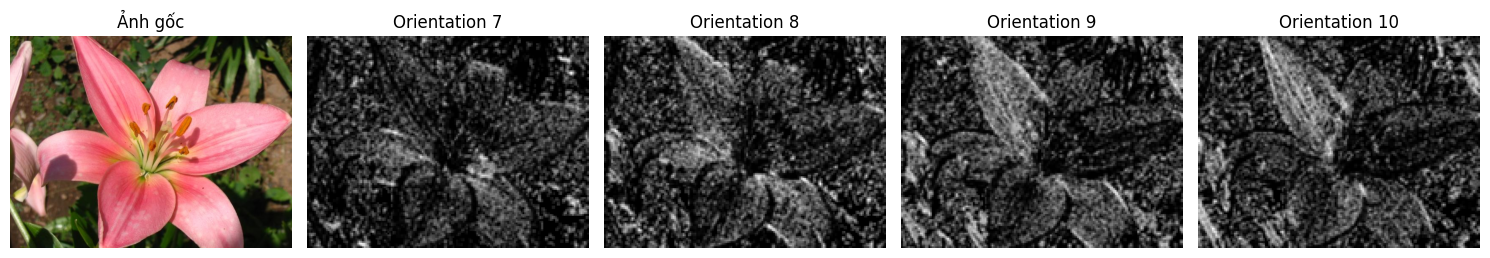

In [1]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import numpy as np

def extract_and_visualize_specific_hog_orientations(image_path):
    """
    Nhập vào một ảnh, trích xuất đặc trưng HOG và hiển thị các kênh định hướng
    được chỉ định (6, 7, 8, 9).

    Args:
        image_path (str): Đường dẫn đến file ảnh.
    """
    # 1. Đọc ảnh
    image = cv2.imread(image_path)
    if image is None:
        print(f"Lỗi: Không thể đọc ảnh từ đường dẫn {image_path}")
        return

    # Chuyển đổi ảnh từ BGR sang RGB để hiển thị với matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 2. Chuyển đổi ảnh sang ảnh xám
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    print(f"Đang trích xuất đặc trưng HOG cho ảnh: {image_path}")

    # 3. Áp dụng HOG để trích xuất đặc trưng
    # Sử dụng 9 orientations, vì 6, 7, 8, 9 (tương ứng index 5, 6, 7, 8) nằm trong phạm vi này.
    num_orientations_to_extract = 11
    fd = hog(gray_image, 
         orientations=num_orientations_to_extract, 
         pixels_per_cell=(4, 4),
         cells_per_block=(2, 2), 
         visualize=False, 
         channel_axis=None, # Hoặc bỏ đi nếu bạn đang dùng scikit-image cũ
         feature_vector=False)
    # Lấy số lượng orientations thực tế từ mảng fd
    num_orientations_actual = fd.shape[-1]
    
    # Tính toán kích thước của ma trận cells
    n_cells_y = fd.shape[0]
    n_cells_x = fd.shape[1]
    
    # Tạo một ma trận để chứa giá trị cường độ cho mỗi orientation tại mỗi cell
    orientation_maps = np.zeros((n_cells_y, n_cells_x, num_orientations_actual))

    # Duyệt qua các blocks và cells để tính trung bình hoặc tổng hợp
    for y in range(n_cells_y):
        for x in range(n_cells_x):
            orientation_maps[y, x, :] = np.mean(fd[y, x], axis=(0, 1))
            
    # Các kênh định hướng muốn hiển thị (index trong mảng, bắt đầu từ 0)
    # Tương ứng với "orientation 6, 7, 8, 9" nếu đếm từ 1
    desired_orientation_indices = [6, 7, 8, 9]  # Chuyển sang index 0-based

    # 4. Hiển thị ảnh gốc và các kênh định hướng được chọn
    plt.figure(figsize=(15, 6)) # Điều chỉnh kích thước figure

    # Ảnh gốc
    plt.subplot(1, 5, 1) # 1 hàng, 5 cột
    plt.imshow(image_rgb)
    plt.title('Ảnh gốc')
    plt.axis('off')

    # Hiển thị từng kênh định hướng được chọn
    for i, orientation_idx in enumerate(desired_orientation_indices):
        if orientation_idx < num_orientations_actual:
            plt.subplot(1, 5, i + 2) # Bắt đầu từ vị trí thứ 2
            
            orientation_channel = orientation_maps[:, :, orientation_idx]
            # Rescale về kích thước ảnh gốc để hiển thị dễ hơn
            orientation_channel_resized = cv2.resize(orientation_channel, (gray_image.shape[1], gray_image.shape[0]), interpolation=cv2.INTER_NEAREST)
            orientation_channel_normalized = exposure.rescale_intensity(orientation_channel_resized, out_range=(0, 1))
            
            plt.imshow(orientation_channel_normalized, cmap='gray')
            plt.title(f'Orientation {orientation_idx + 1}') # Hiển thị theo cách đếm từ 1
            plt.axis('off')
        else:
            print(f"Cảnh báo: Orientation {orientation_idx + 1} không tồn tại (chỉ có {num_orientations_actual} orientations).")
            # Nếu muốn hiển thị một ô trống hoặc thông báo lỗi:
            plt.subplot(1, 5, i + 2)
            plt.text(0.5, 0.5, f'Orientation {orientation_idx + 1}\nKhông tồn tại', 
                     horizontalalignment='center', verticalalignment='center',
                     transform=plt.gca().transAxes, color='red')
            plt.axis('off')

    plt.tight_layout()
    plt.show()
image_path = '/kaggle/input/flowerdatasets/flowers/train/lily/5419048_d1f570fdd0_k.jpg'  # Thay đổi đường dẫn ảnh tại đây
extract_and_visualize_specific_hog_orientations(image_path)

# TRÍCH XUẤT ĐẶC TRƯNG HOG + HSV

In [2]:
import numpy as np
import cv2
import os
from pathlib import Path
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- 1. Hàm Trích xuất Color Histogram HSV ---
def extract_color_hist_hsv(img, bins=(8, 8, 8)):
    """Trích HSV color histogram 3D"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [hsv], [0, 1, 2], None,
        bins,
        [0, 180, 0, 256, 0, 256]
    )
    cv2.normalize(hist, hist) 
    return hist.flatten()

# --- 2. Hàm Trích xuất HOG ---
def extract_hog(img, orientations, resize_shape=(128, 128)):
    """Trích HOG feature cho shape/texture"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(
        gray,
        orientations=orientations, 
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
        channel_axis=None 
    )
    return hog_feat

# --- 3. Hàm Tổng hợp Đặc trưng (HOG + HSV) ---
def extract_features(img_path, orientations, resize_shape=(128, 128)):
    """Đọc ảnh -> resize -> HOG + HSV color hist -> concat"""
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    img = np.ascontiguousarray(img)
    img = cv2.resize(img, resize_shape) 

    hog_feat = extract_hog(img, orientations=orientations, resize_shape=resize_shape)
    color_feat = extract_color_hist_hsv(img, bins=(8, 8, 8))

    features = np.hstack([hog_feat, color_feat])
    return features

# LOAD DATA

In [3]:
# --- 4. Hàm Tải Dữ liệu và Trích xuất Đặc trưng ---
def load_and_extract_features(data_dir, orientations, resize_shape=(128, 128)):
    """Tải đường dẫn ảnh, trích xuất đặc trưng, và mã hóa nhãn."""
    X_features = []
    y_labels = []
    
    data_path = Path(data_dir)
    class_names = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
    
    print(f"Đang tải và trích xuất từ: {data_dir} (Ori={orientations})")

    for class_name in class_names:
        class_path = data_path / class_name
        img_files = list(class_path.glob("*.jpg")) # Tìm file ảnh
        # Thêm các loại file ảnh khác nếu cần...

        for img_path in img_files:
            feats = extract_features(img_path, orientations=orientations, resize_shape=resize_shape)
            
            if feats is not None:
                X_features.append(feats)
                y_labels.append(class_name)

    if not y_labels:
        return np.array([]), np.array([]), class_names

    le = LabelEncoder()
    y_labels_encoded = le.fit_transform(y_labels)

    return np.array(X_features), y_labels_encoded, class_names

# --- CẤU HÌNH VÀ TẢI BAN ĐẦU ---
FLOWER_DATASET_ROOT = '/kaggle/input/flowerdatasets/flowers' 
TRAIN_DIR = os.path.join(FLOWER_DATASET_ROOT, 'train')
VAL_DIR = os.path.join(FLOWER_DATASET_ROOT, 'val')
IMG_SIZE = (128, 128)
DEFAULT_ORIENTATION = 9 

C_list = [10]
gamma_list = ["scale"]
kernel_list = ["rbf"] 
ORIENTATION_VALUES = [7, 8, 9, 10] 

overall_best_model = None
overall_best_val_acc = 0.0
overall_best_orientation = 0
results = []

# Tải dữ liệu ban đầu để kiểm tra
try:
    X_train_base, y_train_base, class_names = load_and_extract_features(TRAIN_DIR, orientations=DEFAULT_ORIENTATION, resize_shape=IMG_SIZE)
    print(f"Kích thước tập huấn luyện gốc: {X_train_base.shape}")
except Exception as e:
    print(f"Lỗi: Không thể tải dữ liệu ban đầu. Vui lòng kiểm tra lại đường dẫn: {FLOWER_DATASET_ROOT}")
    raise e

Đang tải và trích xuất từ: /kaggle/input/flowerdatasets/flowers/train (Ori=9)
Kích thước tập huấn luyện gốc: (8039, 8612)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def apply_scaling_and_pca(X_train, X_val, n_components=0.95):
    """Thực hiện Chuẩn hóa và PCA, chỉ Fit trên tập Train."""
    
    # Chuẩn hóa (Standard Scaling)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) 
    X_val_scaled = scaler.transform(X_val)
    
    # PCA giảm chiều
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    print(f"   [PCA] Kích thước gốc: {X_train_scaled.shape[1]} -> Kích thước sau PCA: {X_train_pca.shape[1]}")
    
    return X_train_pca, X_val_pca

# HUẤN LUYỆN SVM

In [5]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle
# ... (các import khác)

# --- VÒNG LẶP LỒNG NHAU (GRID SEARCH) ---

# Đảm bảo các danh sách tham số C_list, gamma_list, kernel_list đã được định nghĩa
# (Ví dụ: C_list = [0.1, 1, 10, 100], gamma_list = ["scale", "auto", 0.001, 0.01, 0.1], kernel_list = ["rbf", "linear"])

# Reset biến results để lưu trữ metrics chi tiết
results = [] 

for orientation in ORIENTATION_VALUES:
    print("\n==================================================================")
    print(f"🔥 BẮT ĐẦU: Trích xuất đặc trưng với ORIENTATION = {orientation}")
    print("==================================================================")

    # 1. TRÍCH XUẤT ĐẶC TRƯNG MỚI
    try:
        X_train, y_train, _ = load_and_extract_features(TRAIN_DIR, orientation, IMG_SIZE) 
        X_val, y_val, _ = load_and_extract_features(VAL_DIR, orientation, IMG_SIZE)
    except Exception as e:
        print(f"❌ Lỗi tải dữ liệu cho Orientation {orientation}: {e}. Bỏ qua.")
        continue 
    
    # 2. ÁP DỤNG CHUẨN HÓA VÀ PCA
    X_train_for_svm, X_val_for_svm = apply_scaling_and_pca(X_train, X_val)
    
    best_val_acc_for_ori = 0.0
    best_params_for_ori = None
    best_model_for_ori = None

    # 3. GRID SEARCH CHO C và GAMMA
    for C in C_list:
        for gamma in gamma_list:
            for kernel in kernel_list:
                print(f" 	> Đang thử SVM(C={C}, gamma='{gamma}', kernel={kernel}) ...")
                
                clf = SVC(C=C, gamma=gamma, kernel=kernel)
                
                # Huấn luyện trên dữ liệu sau PCA
                clf.fit(X_train_for_svm, y_train) 

                # Đánh giá trên validation
                val_pred = clf.predict(X_val_for_svm) 
                
                # Tính toán các metrics chi tiết (sử dụng average='macro' cho multi-class)
                val_acc = accuracy_score(y_val, val_pred)
                val_precision = precision_score(y_val, val_pred, average='macro', zero_division=0)
                val_recall = recall_score(y_val, val_pred, average='macro', zero_division=0)
                val_f1 = f1_score(y_val, val_pred, average='macro', zero_division=0)
                
                print(f" 	 	--> Val Acc/F1 = {val_acc:.4f} / {val_f1:.4f}")

                current_gamma_used = clf.gamma 

                # Lưu kết quả chi tiết
                results.append({
                    "Orientation": orientation,
                    "Kernel": kernel,
                    "C": C,
                    "Gamma_Setting": gamma,
                    "Gamma_Used": current_gamma_used,
                    "Accuracy": val_acc,
                    "Precision": val_precision,
                    "Recall": val_recall,
                    "F1_Score": val_f1
                })

                # Cập nhật best model cho Orientation hiện tại
                if val_acc > best_val_acc_for_ori:
                    best_val_acc_for_ori = val_acc
                    best_model_for_ori = clf
                    best_params_for_ori = {"C": C, "gamma": gamma, "kernel": kernel}

    # 4. CẬP NHẬT KẾT QUẢ TỔNG THỂ VÀ IN RA
    print(f"\n--- KẾT QUẢ TỐT NHẤT TRONG ORIENTATION {orientation} ---")
    print(f"✅ C đã dùng: {best_model_for_ori.C}")
    print(f"✅ Gamma đã dùng (giá trị thực): {best_model_for_ori.gamma}")
    
    if best_val_acc_for_ori > overall_best_val_acc:
        overall_best_val_acc = best_val_acc_for_ori
        overall_best_model = best_model_for_ori
        overall_best_params = best_params_for_ori
        overall_best_orientation = orientation


print("\n\n#####################################################")
print("🚀 KẾT QUẢ TỐT NHẤT TỔNG THỂ")
print("#####################################################")
print(f"Best Orientation: {overall_best_orientation}")
print(f"Best val accuracy: {overall_best_val_acc:.4f}")
if overall_best_model:
    print(f"Best C đã dùng: {overall_best_model.C}")
    print(f"Best Gamma đã dùng (giá trị thực): {overall_best_model.gamma}")

# ---------------------------------------------------------------------
# 🛑 LƯU MÔ HÌNH TỐT NHẤT 💾
# ---------------------------------------------------------------------

if overall_best_model:
    BEST_MODEL_FILENAME = 'best_svm_pca_hog_classifier.pkl'
    try:
        with open(BEST_MODEL_FILENAME, 'wb') as file:
            pickle.dump(overall_best_model, file)
        print(f"\n✅ Đã lưu mô hình SVM tốt nhất vào file: {BEST_MODEL_FILENAME}")
    except Exception as e:
        print(f"\n❌ Lỗi khi lưu mô hình: {e}")

# ---------------------------------------------------------------------
# 📊 TẠO VÀ IN BẢNG TỔNG KẾT METRICS 📊
# ---------------------------------------------------------------------
print("\n\n#####################################################")
print("📊 BẢNG TỔNG KẾT METRICS GRID SEARCH")
print("#####################################################")

if results:
    df_results = pd.DataFrame(results)
    
    # 1. 🛑 SỬA LỖI: Ép kiểu Gamma_Used về số (float)
    # Sử dụng errors='coerce' để biến chuỗi không phải số (như 'scale') thành NaN
    # Trong trường hợp này, Gamma_Used sẽ KHÔNG chứa 'scale' hay 'auto' nếu logic đúng, 
    # nhưng đây là lớp bảo vệ tốt nhất.
    df_results['Gamma_Used'] = pd.to_numeric(df_results['Gamma_Used'], errors='coerce') 

    # 2. Định dạng lại các cột số để dễ đọc
    df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)
    df_results['Precision'] = df_results['Precision'].map('{:.4f}'.format)
    df_results['Recall'] = df_results['Recall'].map('{:.4f}'.format)
    df_results['F1_Score'] = df_results['F1_Score'].map('{:.4f}'.format)
    
    # 3. Định dạng Gamma_Used (Chỉ áp dụng sau khi chắc chắn nó là số)
    df_results['Gamma_Used'] = df_results['Gamma_Used'].map('{:.6f}'.format)
    # Chọn và hiển thị các cột quan trọng
    display_cols = ["Orientation", "Kernel", "C", "Gamma_Setting", "Accuracy", "F1_Score", "Precision", "Recall"]
    
    # Sắp xếp theo Accuracy (để thấy kết quả tốt nhất)
    df_results['Accuracy_Sort'] = pd.to_numeric(df_results['Accuracy'])
    df_results = df_results.sort_values(by='Accuracy_Sort', ascending=False).drop(columns='Accuracy_Sort')
    
    print(df_results[display_cols].to_markdown(index=False))
else:
    print("Không có kết quả nào được ghi nhận.")


🔥 BẮT ĐẦU: Trích xuất đặc trưng với ORIENTATION = 7
Đang tải và trích xuất từ: /kaggle/input/flowerdatasets/flowers/train (Ori=7)
Đang tải và trích xuất từ: /kaggle/input/flowerdatasets/flowers/val (Ori=7)
   [PCA] Kích thước gốc: 6812 -> Kích thước sau PCA: 1727
 	> Đang thử SVM(C=10, gamma='scale', kernel=rbf) ...
 	 	--> Val Acc/F1 = 0.8097 / 0.8104

--- KẾT QUẢ TỐT NHẤT TRONG ORIENTATION 7 ---
✅ C đã dùng: 10
✅ Gamma đã dùng (giá trị thực): scale

🔥 BẮT ĐẦU: Trích xuất đặc trưng với ORIENTATION = 8
Đang tải và trích xuất từ: /kaggle/input/flowerdatasets/flowers/train (Ori=8)
Đang tải và trích xuất từ: /kaggle/input/flowerdatasets/flowers/val (Ori=8)
   [PCA] Kích thước gốc: 7712 -> Kích thước sau PCA: 1891
 	> Đang thử SVM(C=10, gamma='scale', kernel=rbf) ...
 	 	--> Val Acc/F1 = 0.8019 / 0.8026

--- KẾT QUẢ TỐT NHẤT TRONG ORIENTATION 8 ---
✅ C đã dùng: 10
✅ Gamma đã dùng (giá trị thực): scale

🔥 BẮT ĐẦU: Trích xuất đặc trưng với ORIENTATION = 9
Đang tải và trích xuất từ: /kaggle/

In [7]:
import numpy as np
import cv2
import pickle
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- I. TÁI TẠO CÁC HÀM TRÍCH XUẤT ĐẶC TRƯNG TỪ NOTEBOOK ---

def extract_color_hist_hsv(img, bins=(8, 8, 8)):
    """Trích HSV color histogram 3D và chuẩn hóa L1."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [hsv], [0, 1, 2], None,
        bins,
        [0, 180, 0, 256, 0, 256]
    )
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_L1) 
    return hist.flatten()

def extract_hog(img, orientations):
    """Trích HOG feature."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(
        gray,
        orientations=orientations, 
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
        channel_axis=None 
    )
    return hog_feat

def extract_features(img_path, orientations, resize_shape=(128, 128)):
    """Đọc ảnh -> resize -> HOG + HSV color hist -> concat"""
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    img = np.ascontiguousarray(img)
    img = cv2.resize(img, resize_shape) 

    hog_feat = extract_hog(img, orientations=orientations)
    color_feat = extract_color_hist_hsv(img, bins=(8, 8, 8))

    features = np.hstack([hog_feat, color_feat])
    return features

def load_and_extract_features(data_dir, orientations, resize_shape=(128, 128)):
    """Tải dữ liệu và trích xuất đặc trưng."""
    X_features = []
    y_labels = []
    
    data_path = Path(data_dir)
    class_names = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
    
    for class_name in class_names:
        class_path = data_path / class_name
        img_files = list(class_path.glob("*.jpg")) 

        for img_path in img_files:
            feats = extract_features(img_path, orientations=orientations, resize_shape=resize_shape)
            
            if feats is not None:
                X_features.append(feats)
                y_labels.append(class_name)

    if not y_labels:
        return np.array([]), np.array([]), class_names
    
    return np.array(X_features), np.array(y_labels), class_names


# --- II. THỰC HIỆN FIT CUỐI CÙNG VÀ LƯU ---

# Các giá trị cố định (từ kết quả grid search: Orientation=9, C=10, gamma='scale')
BEST_ORIENTATION = 9
IMAGE_RESIZE_SHAPE = (128, 128)
N_COMPONENTS_PCA = 0.95 
SVC_C = 10
SVC_GAMMA = 'scale'

# CẦN CHỈNH SỬA ĐƯỜNG DẪN GỐC NẾU CẦN
FLOWER_DATASET_ROOT = '/kaggle/input/flowerdatasets/flowers' 
TRAIN_DIR = os.path.join(FLOWER_DATASET_ROOT, 'train')
VAL_DIR = os.path.join(FLOWER_DATASET_ROOT, 'val')

# 1. Tải và trích xuất đặc trưng cho Train và Val
X_train, y_train, class_names = load_and_extract_features(TRAIN_DIR, BEST_ORIENTATION, IMAGE_RESIZE_SHAPE)
X_val, y_val, _ = load_and_extract_features(VAL_DIR, BEST_ORIENTATION, IMAGE_RESIZE_SHAPE)

X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

# 2. Fit StandardScaler và PCA trên tập dữ liệu full (để lưu)
print(f"BƯỚC 1: Đang fit StandardScaler và PCA trên tập dữ liệu full ({X_train_full.shape[0]} mẫu)...")
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full) 

pca = PCA(n_components=N_COMPONENTS_PCA, random_state=42)
X_train_full_pca = pca.fit_transform(X_train_full_scaled)

print(f"   [PCA] Kích thước sau PCA: {X_train_full_pca.shape[1]}")


# 3. Huấn luyện lại model SVC cuối cùng
print("\nBƯỚC 2: Huấn luyện lại model SVC cuối cùng...")
le = LabelEncoder()
y_train_full_encoded = le.fit_transform(y_train_full) # Mã hóa nhãn

svm_final = SVC(C=SVC_C, gamma=SVC_GAMMA, kernel='rbf', random_state=42, probability=True)
svm_final.fit(X_train_full_pca, y_train_full_encoded)

print("   ✅ Huấn luyện model cuối cùng hoàn tất.")


# 4. LƯU TẤT CẢ CÁC THÀNH PHẦN CẦN THIẾT
print("\nBƯỚC 3: Lưu model và các bộ biến đổi vào file PKL...")
model_data = {
    "model": svm_final,
    "scaler": scaler, 
    "pca": pca,
    "class_names": le.classes_.tolist(), # Lưu danh sách tên lớp theo thứ tự
    "orientations": BEST_ORIENTATION,
    "img_size": IMAGE_RESIZE_SHAPE
}

filename = "best_svm_pca_hog_hsv_model.pkl"
with open(filename, "wb") as f:
    pickle.dump(model_data, f)

print(f"   ✅ Đã lưu file thành công: {filename}")

BƯỚC 1: Đang fit StandardScaler và PCA trên tập dữ liệu full (10341 mẫu)...
   [PCA] Kích thước sau PCA: 1916

BƯỚC 2: Huấn luyện lại model SVC cuối cùng...
   ✅ Huấn luyện model cuối cùng hoàn tất.

BƯỚC 3: Lưu model và các bộ biến đổi vào file PKL...
   ✅ Đã lưu file thành công: best_svm_pca_hog_hsv_model.pkl


# ĐÁNH GIÁ MODEL TRÊN TEST SET

BƯỚC 1: Tải model đã lưu...
   ✅ Đã tải model từ best_svm_pca_hog_hsv_model.pkl
   Orientation: 9
   Image size: (128, 128)
   Classes: ['daisy', 'dandelion', 'lily', 'orchid', 'rose', 'sunflower', 'tulip']

BƯỚC 2: Tải và trích xuất đặc trưng test set...
   Kích thước test set: (1153, 8612)

BƯỚC 3: Áp dụng scaling và PCA...
   Kích thước sau PCA: (1153, 1916)

BƯỚC 4: Thực hiện dự đoán trên test set...

📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET

✅ Test Accuracy:  0.7095 (70.95%)
✅ Test Precision: 0.7136 (71.36%)
✅ Test Recall:    0.7119 (71.19%)
✅ Test F1-Score:  0.7126 (71.26%)

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       daisy     0.5753    0.6080    0.5912       176
   dandelion     0.7800    0.7800    0.7800       150
        lily     0.7419    0.7099    0.7256       162
      orchid     0.6721    0.6721    0.6721       183
        rose     0.7133    0.6846    0.6986       149
   sunflower     0.7235    0.7151    0.7193       172
       tulip     

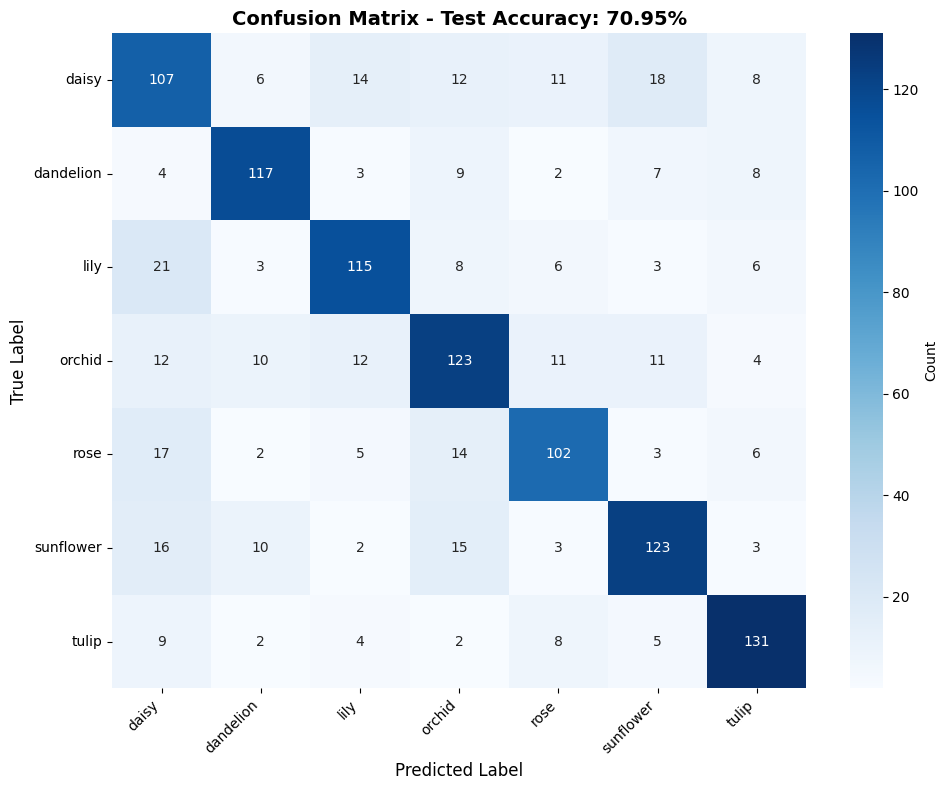


📊 METRICS CHI TIẾT CHO TỪNG CLASS
    Class  Samples  Correct Accuracy Precision Recall F1-Score
    Daisy      176      107   0.6080    0.5753 0.6080   0.5912
Dandelion      150      117   0.7800    0.7800 0.7800   0.7800
     Lily      162      115   0.7099    0.7419 0.7099   0.7256
   Orchid      183      123   0.6721    0.6721 0.6721   0.6721
     Rose      149      102   0.6846    0.7133 0.6846   0.6986
Sunflower      172      123   0.7151    0.7235 0.7151   0.7193
    Tulip      161      131   0.8137    0.7892 0.8137   0.8012

❌ PHÂN TÍCH SAI SÓT
Tổng số dự đoán sai: 335/1153
Tỷ lệ sai: 29.05%

Top 10 cặp class bị nhầm lẫn nhiều nhất:
True Class Predicted As  Count
      Lily        Daisy     21
     Daisy    Sunflower     18
      Rose        Daisy     17
 Sunflower        Daisy     16
 Sunflower       Orchid     15
      Rose       Orchid     14
     Daisy         Lily     14
     Daisy       Orchid     12
    Orchid        Daisy     12
    Orchid         Lily     12

✅ HOÀN T

In [8]:
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. TẢI MODEL ĐÃ LƯU ---
MODEL_FILE = "best_svm_pca_hog_hsv_model.pkl"

print("BƯỚC 1: Tải model đã lưu...")
try:
    with open(MODEL_FILE, 'rb') as f:
        model_data = pickle.load(f)
    print(f"   ✅ Đã tải model từ {MODEL_FILE}")
except FileNotFoundError:
    print(f"   ❌ Lỗi: Không tìm thấy file {MODEL_FILE}")
    raise
except Exception as e:
    print(f"   ❌ Lỗi khi tải model: {e}")
    raise

# Lấy các thành phần
svm_model = model_data['model']
scaler = model_data['scaler']
pca = model_data['pca']
class_names = model_data['class_names']
orientations = model_data['orientations']
img_size = model_data['img_size']

print(f"   Orientation: {orientations}")
print(f"   Image size: {img_size}")
print(f"   Classes: {class_names}")

# --- 2. TẢI VÀ TRÍCH XUẤT ĐẶC TRƯNG TEST SET ---
TEST_DIR = os.path.join(FLOWER_DATASET_ROOT, 'test')

print("\nBƯỚC 2: Tải và trích xuất đặc trưng test set...")
X_test, y_test, _ = load_and_extract_features(TEST_DIR, orientations, img_size)
print(f"   Kích thước test set: {X_test.shape}")

# --- 3. ÁP DỤNG SCALING VÀ PCA ---
print("\nBƯỚC 3: Áp dụng scaling và PCA...")
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
print(f"   Kích thước sau PCA: {X_test_pca.shape}")

# --- 4. DỰ ĐOÁN ---
print("\nBƯỚC 4: Thực hiện dự đoán trên test set...")
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(class_names)
y_test_encoded = le.transform(y_test)

y_pred = svm_model.predict(X_test_pca)

# --- 5. TÍNH TOÁN METRICS ---
print("\n" + "="*60)
print("📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET")
print("="*60)

test_accuracy = accuracy_score(y_test_encoded, y_pred)
test_precision = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)

print(f"\n✅ Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"✅ Test Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"✅ Test Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"✅ Test F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")

# --- 6. CLASSIFICATION REPORT ---
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_encoded, y_pred, target_names=class_names, zero_division=0, digits=4))

# --- 7. CONFUSION MATRIX ---
print("\n" + "="*60)
print("🔲 CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test_encoded, y_pred)
print(cm)

# Vẽ confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Test Accuracy: {test_accuracy*100:.2f}%', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 8. TẠO BẢNG METRICS CHI TIẾT CHO TỪNG CLASS ---
print("\n" + "="*60)
print("📊 METRICS CHI TIẾT CHO TỪNG CLASS")
print("="*60)

# Tính metrics cho từng class
metrics_per_class = []
for i, class_name in enumerate(class_names):
    class_precision = precision_score(y_test_encoded, y_pred, labels=[i], average='macro', zero_division=0)
    class_recall = recall_score(y_test_encoded, y_pred, labels=[i], average='macro', zero_division=0)
    class_f1 = f1_score(y_test_encoded, y_pred, labels=[i], average='macro', zero_division=0)
    
    # Đếm số lượng mẫu
    n_samples = np.sum(y_test_encoded == i)
    n_correct = np.sum((y_test_encoded == i) & (y_pred == i))
    class_accuracy = n_correct / n_samples if n_samples > 0 else 0
    
    metrics_per_class.append({
        'Class': class_name.capitalize(),
        'Samples': n_samples,
        'Correct': n_correct,
        'Accuracy': f"{class_accuracy:.4f}",
        'Precision': f"{class_precision:.4f}",
        'Recall': f"{class_recall:.4f}",
        'F1-Score': f"{class_f1:.4f}"
    })

df_metrics = pd.DataFrame(metrics_per_class)
print(df_metrics.to_string(index=False))

# --- 9. PHÂN TÍCH SAI SÓT ---
print("\n" + "="*60)
print("❌ PHÂN TÍCH SAI SÓT")
print("="*60)

incorrect_predictions = np.where(y_test_encoded != y_pred)[0]
print(f"Tổng số dự đoán sai: {len(incorrect_predictions)}/{len(y_test_encoded)}")
print(f"Tỷ lệ sai: {len(incorrect_predictions)/len(y_test_encoded)*100:.2f}%")

# Tìm các cặp class bị nhầm lẫn nhiều nhất
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'True Class': class_names[i].capitalize(),
                'Predicted As': class_names[j].capitalize(),
                'Count': cm[i, j]
            })

if confusion_pairs:
    df_confusion = pd.DataFrame(confusion_pairs)
    df_confusion = df_confusion.sort_values(by='Count', ascending=False).head(10)
    print("\nTop 10 cặp class bị nhầm lẫn nhiều nhất:")
    print(df_confusion.to_string(index=False))
else:
    print("\n✅ Không có nhầm lẫn giữa các class!")

print("\n" + "="*60)
print("✅ HOÀN TẤT ĐÁNH GIÁ")
print("="*60)


Ảnh đầu vào: /kaggle/input/test-demo/image42-1660292012-557-width2048height1560.jpg
Kích thước vector đặc trưng sau PCA: 1916
🌼 KẾT QUẢ DỰ ĐOÁN: ORCHID
Độ tin cậy: 38.41%

--- Xác suất chi tiết ---
Orchid: 38.41%
Sunflower: 35.47%
Dandelion: 11.10%
Rose: 9.60%
Daisy: 3.59%
Lily: 1.37%
Tulip: 0.45%


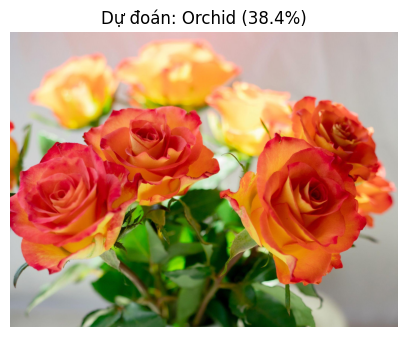

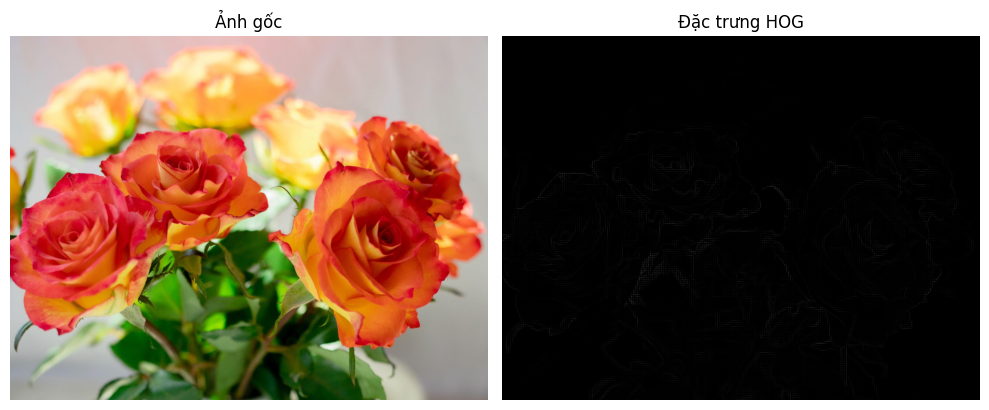

In [9]:
# --- HÀM TRÍCH XUẤT ĐẶC TRƯNG CHO DEMO ---
# (Sử dụng lại các biến đã load từ cell đánh giá: svm_model, scaler, pca, class_names, orientations, img_size)

def extract_color_hist_hsv_demo(img, bins=(8, 8, 8)):
    """Trích HSV color histogram 3D và chuẩn hóa."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [hsv], [0, 1, 2], None,
        bins,
        [0, 180, 0, 256, 0, 256]
    )
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_L1) 
    return hist.flatten()

def extract_hog_demo(img, orientations):
    """Trích HOG feature với các tham số đã dùng trong huấn luyện."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(
        gray,
        orientations=orientations, 
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
        channel_axis=None 
    )
    return hog_feat

def get_final_feature_vector(img_bgr):
    """Thực hiện toàn bộ quá trình: Resize, HOG, HSV, Concat, Scale, PCA.
    Sử dụng các biến global đã load từ cell đánh giá."""
    
    # 1. Resize ảnh
    img_resized = cv2.resize(img_bgr, img_size)
    img_resized = np.ascontiguousarray(img_resized) 

    # 2. Trích xuất HOG và HSV
    hog_feat = extract_hog_demo(img_resized, orientations=orientations)
    color_feat = extract_color_hist_hsv_demo(img_resized)

    # 3. Nối (Concatenate)
    features = np.hstack([hog_feat, color_feat])
    features = features.reshape(1, -1)

    # 4. Chuẩn hóa (Scaling)
    features_scaled = scaler.transform(features)

    # 5. Giảm chiều (PCA)
    features_pca = pca.transform(features_scaled)
    
    return features_pca

# --- HÀM DỰ ĐOÁN & DEMO ---
def demo_prediction(image_path):
    """Trích xuất đặc trưng và dự đoán cho ảnh.
    Sử dụng model đã load từ cell đánh giá."""
    
    # 1. Đọc và tiền xử lý ảnh
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Lỗi: Không thể đọc ảnh từ đường dẫn {image_path}")
        return

    # 2. Trích xuất vector đặc trưng cuối cùng
    feature_vector_pca = get_final_feature_vector(img_bgr)
    
    # 3. Dự đoán (sử dụng svm_model đã load)
    prediction_index = svm_model.predict(feature_vector_pca)[0]
    predicted_class = class_names[prediction_index]
    
    # Lấy xác suất
    probabilities = svm_model.predict_proba(feature_vector_pca)[0]
    confidence = probabilities[prediction_index] * 100

    print("\n=============================================")
    print(f"Ảnh đầu vào: {image_path}")
    print(f"Kích thước vector đặc trưng sau PCA: {feature_vector_pca.shape[1]}")
    print(f"🌼 KẾT QUẢ DỰ ĐOÁN: {predicted_class.upper()}")
    print(f"Độ tin cậy: {confidence:.2f}%")
    print("=============================================")

    # Hiển thị bảng chi tiết xác suất
    sorted_indices = np.argsort(probabilities)[::-1]
    print("\n--- Xác suất chi tiết ---")
    for i in sorted_indices:
        print(f"{class_names[i].capitalize()}: {probabilities[i]*100:.2f}%")
        
    # Hiển thị ảnh
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Dự đoán: {predicted_class.capitalize()} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()


# --- HÀM TRÍCH XUẤT VÀ HIỂN THỊ ĐẶC TRƯNG HOG ---
def extract_and_visualize_hog(image_path, orientations, pixels_per_cell, cells_per_block):
    """Trích xuất và hiển thị HOG feature cho ảnh mới."""
    
    # Đọc ảnh
    image = cv2.imread(image_path)
    if image is None:
        print(f"Lỗi: Không thể đọc ảnh từ đường dẫn {image_path}")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Áp dụng HOG
    fd, hog_image = hog(
        gray_image, 
        orientations=orientations, 
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block, 
        block_norm="L2-Hys",
        transform_sqrt=True,
        visualize=True,
        feature_vector=True
    )
    
    # Rescale HOG image để hiển thị
    hog_image_rescaled = exposure.rescale_intensity(hog_image, out_range=(0, 255))
    hog_image_rescaled = hog_image_rescaled.astype(np.uint8)

    # Hiển thị
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Ảnh gốc')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(hog_image_rescaled, cmap='gray')
    plt.title('Đặc trưng HOG')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
# --- CHẠY DEMO ---
# THAY THẾ ĐƯỜNG DẪN ẢNH DEMO CỦA BẠN TẠI ĐÂY
demo_image_path = '/kaggle/input/test-demo/image42-1660292012-557-width2048height1560.jpg' 

# DEMO 1: Dự đoán
demo_prediction(demo_image_path)

# DEMO 2: Trích xuất và hiển thị ảnh HOG
extract_and_visualize_hog(
    image_path=demo_image_path,
    orientations=9, 
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
)